In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

from sklearn.metrics import root_mean_squared_error


In [2]:
features_to_train = ["temp_actual", "temp_6h_actual", "CDH_actual", "HDH_actual", "temp_actual_lag_24h", "Load_lag_24h", "Load_lag_48h", "is_weekend", "is_notable_day"]

train_loc = "../data/processed/day_ahead_train.csv"
test_loc = "../data/processed/day_ahead_test.csv"

df_train = pd.read_csv(train_loc)
df_test = pd.read_csv(test_loc)

In [3]:
with open('../trained_models/day_ahead_linears.pkl', 'rb') as file:
    day_ahead_linears = pickle.load(file)

with open('../trained_models/day_ahead_ridges.pkl', 'rb') as file:
    day_ahead_ridges = pickle.load(file)

with open('../trained_models/day_ahead_lassos.pkl', 'rb') as file:
    day_ahead_lassos = pickle.load(file)

with open('../trained_models/day_ahead_xgbs_best_per_hour_xgbs.pkl', 'rb') as file:
    day_ahead_xgbs_best_per_hour_xgbs = pickle.load(file)

with open('../trained_models/day_ahead_xgbs_best_max_hour_xgbs.pkl', 'rb') as file:
    day_ahead_xgbs_best_max_hour_xgbs = pickle.load(file)

with open('../trained_models/day_ahead_lin_xgbs_best_per_hour_xgbs.pkl', 'rb') as file:
    day_ahead_lin_xgbs_best_per_hour_xgbs = pickle.load(file)

with open('../trained_models/day_ahead_lin_xgbs_best_max_hour_xgbs.pkl', 'rb') as file:
    day_ahead_lin_xgbs_best_max_hour_xgbs = pickle.load(file)


best_per_hour_lin_xgb_hyperparams = pd.read_csv("../src/models/best_per_hour_lin_xgb_hyperparams.csv")
best_max_hour_lin_xgb_hyperparams = pd.read_csv("../src/models/best_max_hour_lin_xgb_hyperparams.csv")
best_per_hour_xgb_hyperparams = pd.read_csv("../src/models/best_per_hour_xgb_hyperparams.csv")
best_max_hour_xgb_hyperparams = pd.read_csv("../src/models/best_max_hour_xgb_hyperparams.csv")

splits_df_loc = "../data/splits/split_bounds.csv"
splits_df = pd.read_csv(splits_df_loc)

ridge_alpha = 32
lasso_alpha = 3.6

In [4]:
def cv_rmse(model_name, input_df):

    match model_name:
        case "linears":
            models = [LinearRegression() for hour in range(0, 24)]
            
        case "ridges":
            models = [Ridge(alpha = ridge_alpha) for hour in range(0, 24)]
            
        case "lassos":
            models = [Lasso(alpha = lasso_alpha) for hour in range(0, 24)]
            
        case "xgb_best_per_hour":
            models = [XGBRegressor(objective='reg:squarederror', 
                                   n_estimators = int(best_per_hour_xgb_hyperparams.iloc[hour]["n_estimators"]), 
                                   learning_rate = best_per_hour_xgb_hyperparams.iloc[hour]["learning_rate"], 
                                   max_depth = int(best_per_hour_xgb_hyperparams.iloc[hour]["max_depth"]), 
                                   min_child_weight = int(best_per_hour_xgb_hyperparams.iloc[hour]["min_child_weight"]), 
                                   subsample = 0.8, 
                                   random_state = 12) 
                      for hour in range(0,24)]
        
        case "xgb_best_max_hour":
            models = [XGBRegressor(objective='reg:squarederror', 
                                   n_estimators = int(best_max_hour_xgb_hyperparams.iloc[0]["n_estimators"]), 
                                   learning_rate = best_max_hour_xgb_hyperparams.iloc[0]["learning_rate"], 
                                   max_depth = int(best_max_hour_xgb_hyperparams.iloc[0]["max_depth"]), 
                                   min_child_weight = int(best_max_hour_xgb_hyperparams.iloc[0]["min_child_weight"]), 
                                   subsample = 0.8, 
                                   random_state = 12) 
                      for hour in range(0,24)]
        case "lin_xgb_best_per_hour":
            lin_models = [LinearRegression() for hour in range(0, 24)]
            
            xgb_models = [XGBRegressor(objective='reg:squarederror', 
                                   n_estimators = int(best_per_hour_lin_xgb_hyperparams.iloc[hour]["n_estimators"]), 
                                   learning_rate = best_per_hour_lin_xgb_hyperparams.iloc[hour]["learning_rate"], 
                                   max_depth = int(best_per_hour_lin_xgb_hyperparams.iloc[hour]["max_depth"]), 
                                   min_child_weight = int(best_per_hour_lin_xgb_hyperparams.iloc[hour]["min_child_weight"]), 
                                   subsample = 0.8, 
                                   random_state = 12) 
                      for hour in range(0,24)]
        case "lin_xgb_best_max_hour":
            lin_models = [LinearRegression() for hour in range(0, 24)]
            
            xgb_models = [XGBRegressor(objective='reg:squarederror', 
                                   n_estimators = int(best_max_hour_lin_xgb_hyperparams.iloc[0]["n_estimators"]), 
                                   learning_rate = best_max_hour_lin_xgb_hyperparams.iloc[0]["learning_rate"], 
                                   max_depth = int(best_max_hour_lin_xgb_hyperparams.iloc[0]["max_depth"]), 
                                   min_child_weight = int(best_max_hour_lin_xgb_hyperparams.iloc[0]["min_child_weight"]), 
                                   subsample = 0.8, 
                                   random_state = 12) 
                      for hour in range(0,24)] 
            
    split_rmses = []
    
    for i in range(1, splits_df.shape[0] + 1):

        split = f"split_{i}"
        row = splits_df[splits_df["split"] == split].iloc[0]

        all_squared_errors = []
            
        for hour in range(0, 24):
            
            train_start_date = row["train_start_date"]
            train_end_date = row["train_end_date"]
            val_start_date = row["val_start_date"]
            val_end_date = row["val_end_date"]
            
            train_mask = (input_df["timestamp"] >= train_start_date) & (input_df["timestamp"] < train_end_date) & (input_df["Hour"] == hour)
            val_mask = (input_df["timestamp"] >= val_start_date) & (input_df["timestamp"] < val_end_date) & (input_df["Hour"] == hour)
            
            X_train = input_df[train_mask].drop(columns=["timestamp", "Load"])
            y_train = input_df[train_mask]["Load"]
            
            X_val = input_df[val_mask].drop(columns=["timestamp", "Load"])
            y_val = input_df[val_mask]["Load"]
            
            if model_name[:7] == "lin_xgb":
                
                n_train_samples = len(X_train)
                initial_len = int(0.6 * n_train_samples)
                step_size = 7
                
                oos_residuals = np.full(n_train_samples, np.nan)
        
                for start in range(initial_len, n_train_samples, step_size):
                    end = min(start + step_size, n_train_samples)
        
                    wf_lin = LinearRegression()
                    wf_lin.fit(X_train.iloc[:start], y_train.iloc[:start])
                
                    preds = wf_lin.predict(X_train.iloc[start:end])
        
                    oos_residuals[start:end] = y_train.iloc[start:end] - preds
        
                mask = ~np.isnan(oos_residuals)
        
                xgb_models[hour].fit(X_train.iloc[mask], oos_residuals[mask])
        
                lin_models[hour].fit(X_train, y_train)
            
                y_lin_pred = lin_models[hour].predict(X_val)
                y_xgbr_pred = xgb_models[hour].predict(X_val)
    
                y_pred = y_lin_pred + y_xgbr_pred
                
            else:
                models[hour].fit(X_train, y_train)
                y_pred = models[hour].predict(X_val)
    
            all_squared_errors.extend((y_val - y_pred) ** 2)
        
        split_rmse = np.sqrt(np.mean(all_squared_errors))
        split_rmses.append(split_rmse)
        
    return np.mean(split_rmses), np.std(split_rmses)


In [86]:
def generate_all_predictions(model_name, input_df):
    
    if model_name == "linears":
        models = day_ahead_linears
        is_lin_xgb = False
    elif model_name == "ridges":
        models = day_ahead_ridges
        is_lin_xgb = False
    elif model_name == "lassos":
        models = day_ahead_lassos
        is_lin_xgb = False
    elif model_name == "xgb_best_per_hour":
        models = day_ahead_xgbs_best_per_hour_xgbs
        is_lin_xgb = False
    elif model_name == "xgb_best_max_hour":
        models = day_ahead_xgbs_best_max_hour_xgbs
        is_lin_xgb = False
    elif model_name == "lin_xgb_best_per_hour":
        lin_models = day_ahead_linears
        xgb_models = day_ahead_lin_xgbs_best_per_hour_xgbs
        is_lin_xgb = True
    elif model_name == "lin_xgb_best_max_hour":
        lin_models = day_ahead_linears
        xgb_models = day_ahead_lin_xgbs_best_max_hour_xgbs
        is_lin_xgb = True
    else:
        raise ValueError(f"Invalid model name: {model_name}")

    preds_list = []

    for hour in range(24):
        hour_mask = input_df["Hour"] == hour
        X_hour = input_df.loc[hour_mask].drop(columns=["timestamp", "Load", "Hour"])

        if len(X_hour) == 0:
            continue

        if is_lin_xgb:
            y_pred_hour = lin_models[hour].predict(X_hour) + xgb_models[hour].predict(X_hour)
        else:
            y_pred_hour = models[hour].predict(X_hour)

        preds_hour_df = pd.DataFrame({
            "timestamp": input_df.loc[hour_mask, "timestamp"],
            "prediction": y_pred_hour
        }, index=input_df.loc[hour_mask].index)

        preds_list.append(preds_hour_df)

    all_preds_df = pd.concat(preds_list)
    all_preds_df = all_preds_df.sort_index()
    return all_preds_df["prediction"]


In [24]:
input_df_train = df_train[["timestamp", "Load", "Hour"] + ["temp_actual", "temp_6h_actual", "CDH_actual", "HDH_actual", "temp_actual_lag_24h", "Load_lag_24h", "Load_lag_48h", "is_weekend", "is_notable_day"]
]
input_df_test = df_test[["timestamp", "Load", "Hour"] + ["temp_actual", "temp_6h_actual", "CDH_actual", "HDH_actual", "temp_actual_lag_24h", "Load_lag_24h", "Load_lag_48h", "is_weekend", "is_notable_day"]
]

model_names = ["linears", "ridges", "lassos", "xgb_best_per_hour", "xgb_best_max_hour", "lin_xgb_best_per_hour", "lin_xgb_best_max_hour"]

errors_dict = {"model_name": model_names, "train_error" : [], "validation_error": [], "validation_std": [], "test_error": [], "test_error_pct_max": []}

max_load_train = input_df_train["Load"].max()
max_load_test = input_df_test["Load"].max()

for model_name in errors_dict["model_name"]:

    train_error = root_mean_squared_error(generate_all_predictions(model_name, input_df_train), input_df_train["Load"])

    validation_error, validation_std = cv_rmse(model_name, input_df_train)
    
    test_errors = []
    
    test_error = root_mean_squared_error(generate_all_predictions(model_name, input_df_test), input_df_test["Load"])
    test_errors.append(test_error)
    
    errors_dict["train_error"].append(train_error)
    errors_dict["validation_error"].append(validation_error)
    errors_dict["validation_std"].append(validation_std)
    errors_dict["test_error"].append(np.mean(test_errors))
    errors_dict["test_error_pct_max"].append(100*np.mean(test_errors)/max_load_test)

errors_df = pd.DataFrame(errors_dict)

In [26]:
errors_df

,model_name,train_error,validation_error,validation_std,test_error,test_error_pct_max
0,linears,148.628481,157.548397,8.835426,156.861845,3.385751
1,ridges,149.602125,159.828714,9.109033,158.315324,3.417123
2,lassos,149.371866,158.067646,8.695638,157.931509,3.408839
3,xgb_best_per_hour,106.150352,148.891497,9.127180,155.903541,3.365067
4,xgb_best_max_hour,102.721747,150.183523,9.230271,155.545488,3.357338
5,lin_xgb_best_per_hour,131.064738,173.880840,18.999788,147.756348,3.189215
6,lin_xgb_best_max_hour,130.746953,174.935766,19.971553,146.997596,3.172838


In [100]:
temp_uncertainties = [i for i in range (1, 11)]

model_names = ["linears", "ridges", "lassos", "xgb_best_per_hour", "xgb_best_max_hour", "lin_xgb_best_per_hour", "lin_xgb_best_max_hour"]

def monte_carlo_temp_sensitivity(
    input_df_test,
    model_names,
    temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=None
):
    
    temp_uncertainties_errors_dict = {
        "model_name": [],
        "temp_uncertainty": [],
        "test_error": [],
        "test_std": []
    }
    
    input_df_test["timestamp"] = pd.to_datetime(input_df_test["timestamp"])


    test_df_component_1 = input_df_test[["timestamp", "Load", "Hour"]]
    test_df_component_2 = input_df_test[
        ["temp_actual_lag_24h", "Load_lag_24h", "Load_lag_48h", "is_weekend", "is_notable_day"]
    ]
    

    print("=" * 80)
    print("MONTE CARLO SENSITIVITY ANALYSIS: LOAD FORECAST VS TEMPERATURE UNCERTAINTY")
    print(f"Total Models: {len(model_names)} | Uncertainty Levels: {len(temp_uncertainties)} | Simulations per Level: {n_simulations}")
    print("=" * 80)

    for model_idx, model_name in enumerate(model_names, 1):

        # Model performance on test set with actual temperatures

        if filter_fn is not None:
            mask = filter_fn(input_df_test)
            df_eval = input_df_test.loc[mask]
        else:
            df_eval = input_df_test

        if len(df_eval) == 0:
            continue

        preds = generate_all_predictions(model_name, df_eval)
        test_error_actual = root_mean_squared_error(preds, df_eval["Load"])

        temp_uncertainties_errors_dict["model_name"].append(model_name)
        temp_uncertainties_errors_dict["temp_uncertainty"].append(0)
        temp_uncertainties_errors_dict["test_error"].append(test_error_actual)
        temp_uncertainties_errors_dict["test_std"].append(0.0)

        print("\n" + "-" * 80)
        print(f"[MODEL {model_idx}/{len(model_names)}] Evaluating: {model_name}")
        print("-" * 80)

        for unc_idx, temp_uncertainty in enumerate(temp_uncertainties, 1):

            print(
                f"\n  → Temperature Uncertainty σ = {temp_uncertainty}°F "
                f"({unc_idx}/{len(temp_uncertainties)}) | Running {n_simulations} Monte Carlo sims..."
            )

            temp_uncertainties_errors_dict["model_name"].append(model_name)
            temp_uncertainties_errors_dict["temp_uncertainty"].append(temp_uncertainty)

            rmse_list = []

            for i in range(n_simulations):
                simulated_temp = simulate_long_forecast(
                    input_df_test["temp_actual"],
                    std=temp_uncertainty,
                    correlation_factor=0.5
                )

                test_df_simulated = pd.DataFrame(simulated_temp)
                test_df_simulated["temp_6h_simulated"] = test_df_simulated["temp_simulated"].rolling(6).mean()
                test_df_simulated = test_df_simulated.dropna()

                test_df_simulated["CDH_simulated"] = (test_df_simulated["temp_simulated"] - base_t).clip(lower=0)
                test_df_simulated["HDH_simulated"] = (base_t - test_df_simulated["temp_simulated"]).clip(lower=0)

                valid_index = test_df_simulated.index

                input_df_simulated = pd.concat(
                    [
                        test_df_component_1.loc[valid_index],
                        test_df_simulated,
                        test_df_component_2.loc[valid_index],
                    ],
                    axis=1,
                )

                input_df_simulated = input_df_simulated.rename(
                    columns={
                        "temp_simulated": "temp_actual",
                        "temp_6h_simulated": "temp_6h_actual",
                        "CDH_simulated": "CDH_actual",
                        "HDH_simulated": "HDH_actual",
                    }
                )

                if filter_fn is not None:
                    mask = filter_fn(input_df_simulated)
                    df_eval = input_df_simulated.loc[mask]
                else:
                    df_eval = input_df_simulated

                if len(df_eval) == 0:
                    continue

                preds = generate_all_predictions(model_name, df_eval)
                rmse = root_mean_squared_error(preds, df_eval["Load"])
                rmse_list.append(rmse)

            temp_uncertainties_errors_dict["test_error"].append(np.mean(rmse_list))
            temp_uncertainties_errors_dict["test_std"].append(np.std(rmse_list))

            print(
                f"  ✔ Completed σ = {temp_uncertainty}°F | "
                f"Mean RMSE: {np.mean(rmse_list):.4f} | Std: {np.std(rmse_list):.4f}"
            )

    return pd.DataFrame(temp_uncertainties_errors_dict)


In [102]:
temp_uncertainties_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=None
)

/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_73648/610575064.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df_test["timestamp"] = pd.to_datetime(input_df_test["timestamp"])


MONTE CARLO SENSITIVITY ANALYSIS: LOAD FORECAST VS TEMPERATURE UNCERTAINTY
Total Models: 7 | Uncertainty Levels: 10 | Simulations per Level: 100

--------------------------------------------------------------------------------
[MODEL 1/7] Evaluating: linears
--------------------------------------------------------------------------------

  → Temperature Uncertainty σ = 1°F (1/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 1°F | Mean RMSE: 159.5210 | Std: 0.4457

  → Temperature Uncertainty σ = 2°F (2/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 2°F | Mean RMSE: 164.0912 | Std: 0.9766

  → Temperature Uncertainty σ = 3°F (3/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 3°F | Mean RMSE: 171.6364 | Std: 1.2676

  → Temperature Uncertainty σ = 4°F (4/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 4°F | Mean RMSE: 182.3533 | Std: 1.7198

  → Temperature Uncertainty σ = 5°F (5/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 5°F | Mean RMSE: 197

In [106]:
temp_uncertainties_df

,model_name,temp_uncertainty,test_error,test_std
0,linears,0,156.861845,0.000000
1,linears,1,159.520988,0.445733
2,linears,2,164.091217,0.976585
3,linears,3,171.636394,1.267563
4,linears,4,182.353269,1.719773
...,...,...,...,...
72,lin_xgb_best_max_hour,6,248.285767,3.773142
73,lin_xgb_best_max_hour,7,273.672062,4.242720
74,lin_xgb_best_max_hour,8,299.797346,5.048763
75,lin_xgb_best_max_hour,9,325.882910,5.830648


In [108]:
hour_filters = []

for hour in range(0, 24):
    hour_filter = lambda df: df["Hour"] == hour
    hour_filters.append(hour_filter)

In [120]:
hours_df_total = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=hour_filters[0]
)

hours_df_total["Hour"] = 0

for hour in range(1, 2):

    hour_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties, n_simulations=100, base_t=60, filter_fn=hour_filters[hour])

    hour_df["Hour"] = hour

    hours_df_total = pd.concat([hours_df_total, hour_df], axis = 0)


/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_73648/610575064.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df_test["timestamp"] = pd.to_datetime(input_df_test["timestamp"])


MONTE CARLO SENSITIVITY ANALYSIS: LOAD FORECAST VS TEMPERATURE UNCERTAINTY
Total Models: 7 | Uncertainty Levels: 10 | Simulations per Level: 100

--------------------------------------------------------------------------------
[MODEL 1/7] Evaluating: linears
--------------------------------------------------------------------------------

  → Temperature Uncertainty σ = 1°F (1/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 1°F | Mean RMSE: 226.8978 | Std: 1.5138

  → Temperature Uncertainty σ = 2°F (2/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 2°F | Mean RMSE: 232.7100 | Std: 3.1359

  → Temperature Uncertainty σ = 3°F (3/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 3°F | Mean RMSE: 241.0666 | Std: 4.6489

  → Temperature Uncertainty σ = 4°F (4/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 4°F | Mean RMSE: 252.1560 | Std: 5.6957

  → Temperature Uncertainty σ = 5°F (5/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 5°F | Mean RMSE: 266

/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_73648/610575064.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df_test["timestamp"] = pd.to_datetime(input_df_test["timestamp"])


  ✔ Completed σ = 1°F | Mean RMSE: 96.9328 | Std: 0.7059

  → Temperature Uncertainty σ = 2°F (2/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 2°F | Mean RMSE: 98.9348 | Std: 1.6722

  → Temperature Uncertainty σ = 3°F (3/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 3°F | Mean RMSE: 101.9709 | Std: 2.1903

  → Temperature Uncertainty σ = 4°F (4/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 4°F | Mean RMSE: 105.9993 | Std: 2.7073

  → Temperature Uncertainty σ = 5°F (5/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 5°F | Mean RMSE: 110.6865 | Std: 3.2835

  → Temperature Uncertainty σ = 6°F (6/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 6°F | Mean RMSE: 115.1753 | Std: 3.7023

  → Temperature Uncertainty σ = 7°F (7/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 7°F | Mean RMSE: 120.6780 | Std: 4.1221

  → Temperature Uncertainty σ = 8°F (8/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 8°F | Mean RMSE: 126.5545 | Std:

In [ ]:
summer_months = [6, 7, 8]

summer_filter = lambda df: df["timestamp"].dt.month.isin(summer_months)

winter_months = [11, 12, 1, 2]

winter_filter = lambda df: df["timestamp"].dt.month.isin(winter_months)

winter_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=winter_filter
)

winter_df["Season"] = "Winter"

summer_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=summer_filter
)

summer_df["Season"] = "Summer"


seasonal_test_df = pd.concat([winter_df, summer_df], axis = 0)



In [ ]:
weekend_filter = lambda df: df["is_weekend"] == 1

weekday_filter = lambda df: df["is_weekend"] == 0

weekend_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=weekend_filter
)

summer_df["is_weekend"] = 1

weekday_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=weekday_filter
)

summer_df["is_weekend"] = 0

weekday_weekend_test_df = pd.concat([weekend_df, weekday_df], axis = 0)



In [ ]:
top_10_pct_load_filter = lambda df: df["Load"] >= df["Load"].quantile(90)

top_10_pct_load_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=top_10_pct_load_filter
)

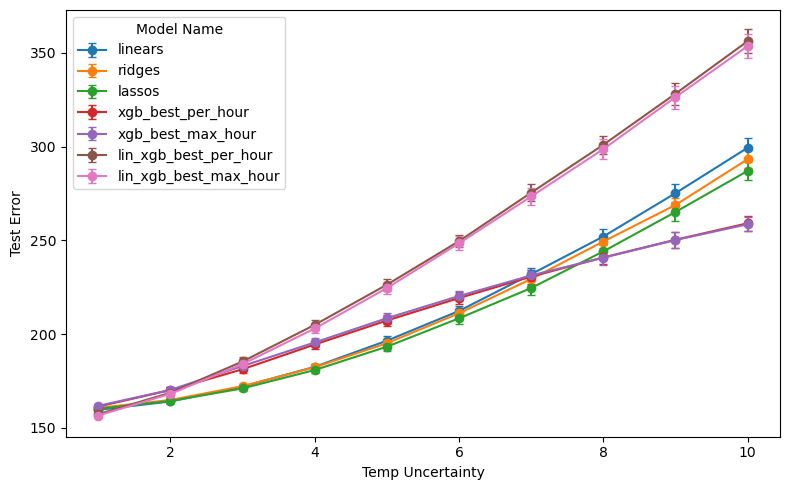

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))

for model_name in model_names:
    
    x = outs_df[outs_df["model_name"] == model_name]["temp_uncertainty"]
    y = outs_df[outs_df["model_name"] == model_name]["test_error"]
    yerr = outs_df[outs_df["model_name"] == model_name]["test_std"]

    ax.errorbar(x, y, yerr=yerr, label=model_name, marker="o", capsize=3)

ax.set_xlabel("Temp Uncertainty")
ax.set_ylabel("Test Error")
ax.legend(title="Model Name")
plt.tight_layout()
plt.show()

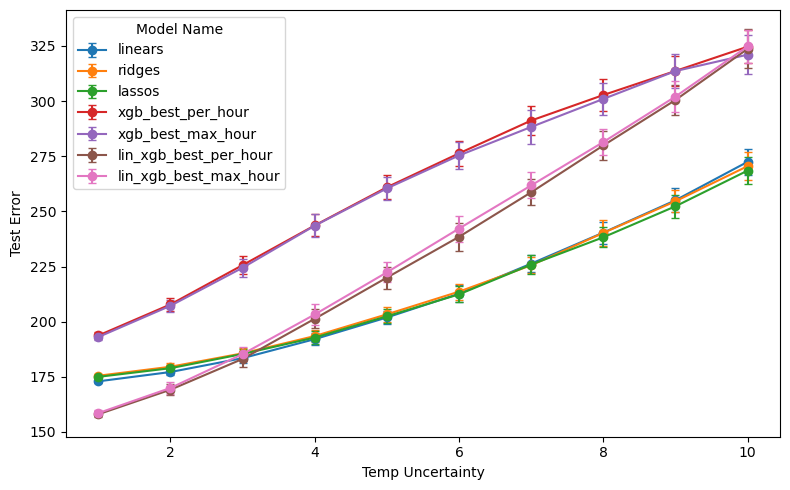

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))

for model_name in model_names:
    
    x = outs_df[outs_df["model_name"] == model_name]["temp_uncertainty"]
    y = outs_df[outs_df["model_name"] == model_name]["test_error"]
    yerr = outs_df[outs_df["model_name"] == model_name]["test_std"]

    ax.errorbar(x, y, yerr=yerr, label=model_name, marker="o", capsize=3)

ax.set_xlabel("Temp Uncertainty")
ax.set_ylabel("Test Error")
ax.legend(title="Model Name")
plt.tight_layout()
plt.show()